# **KNN Interpolation: Comparing Different Neighbour Counts**

### Evaluating KNN Performance with 2 vs. 10 Neighbours

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt


Performing KNN Interpolation with 2 Neighbours...

Processing Delta Band...


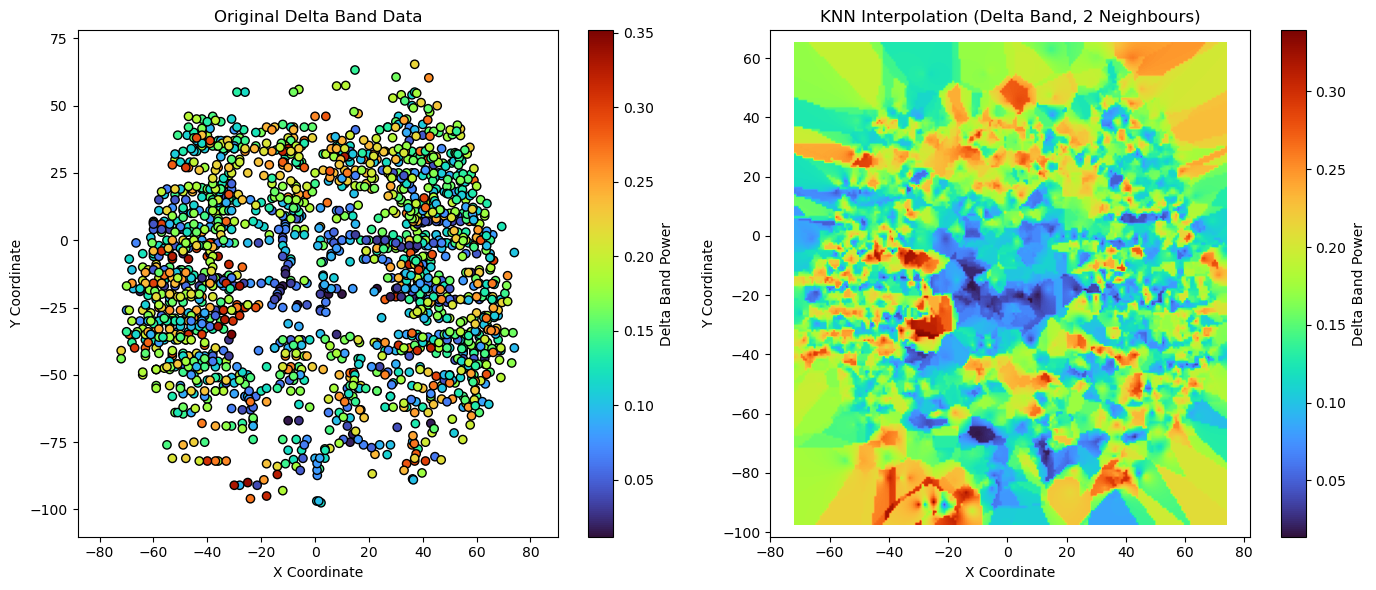

Processing Theta Band...


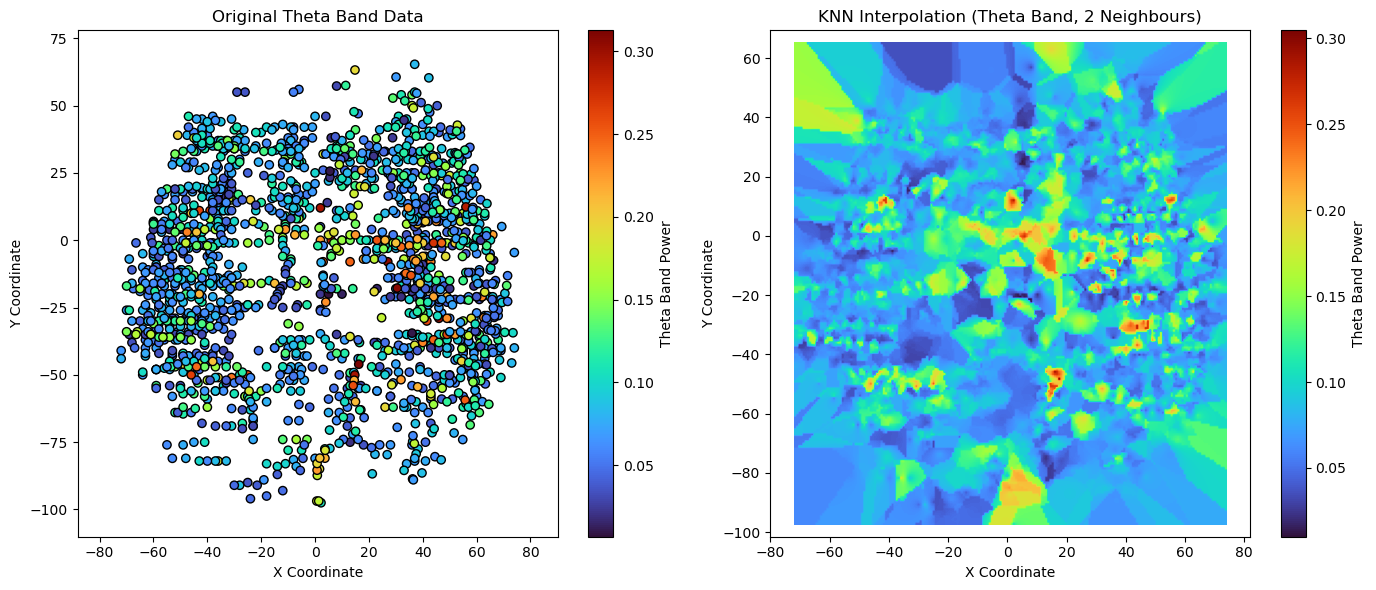

Processing Alpha Band...


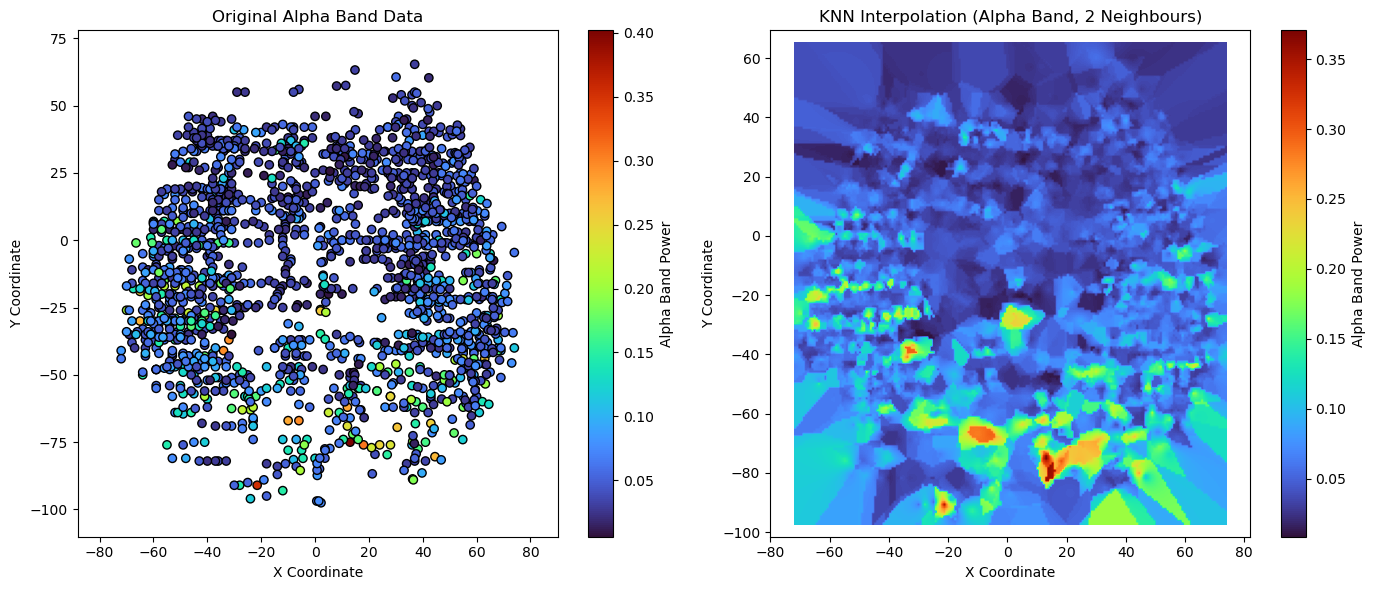

Processing Beta Band...


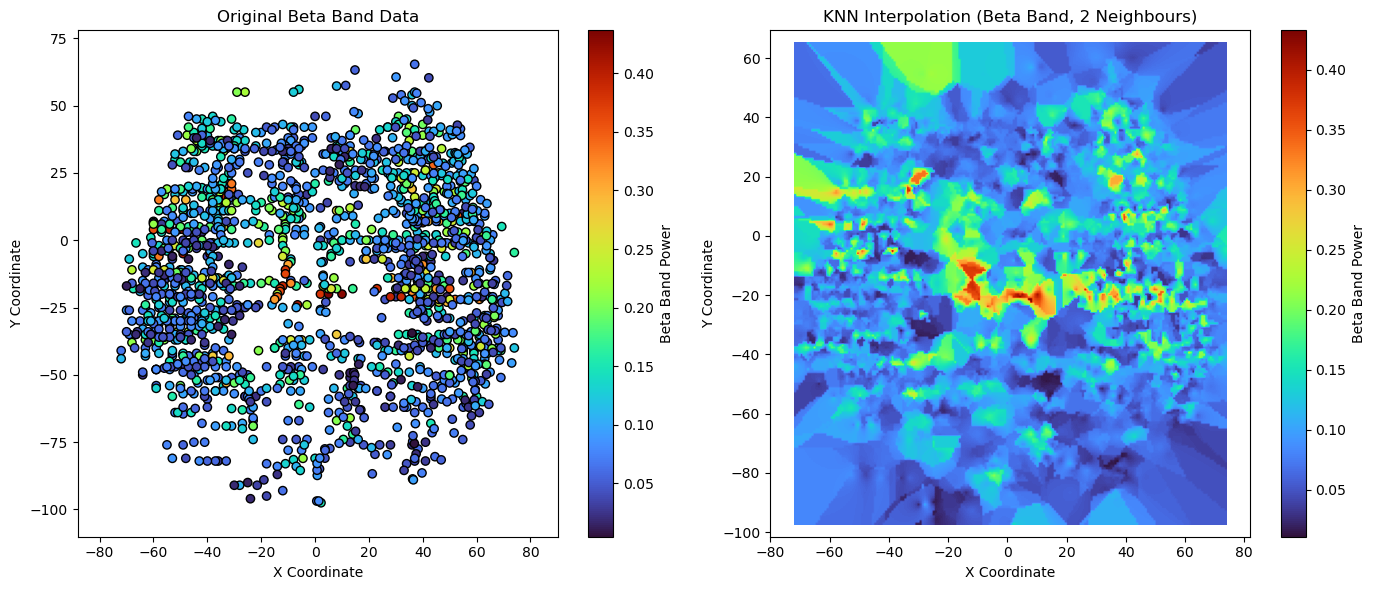

Processing Gamma Band...


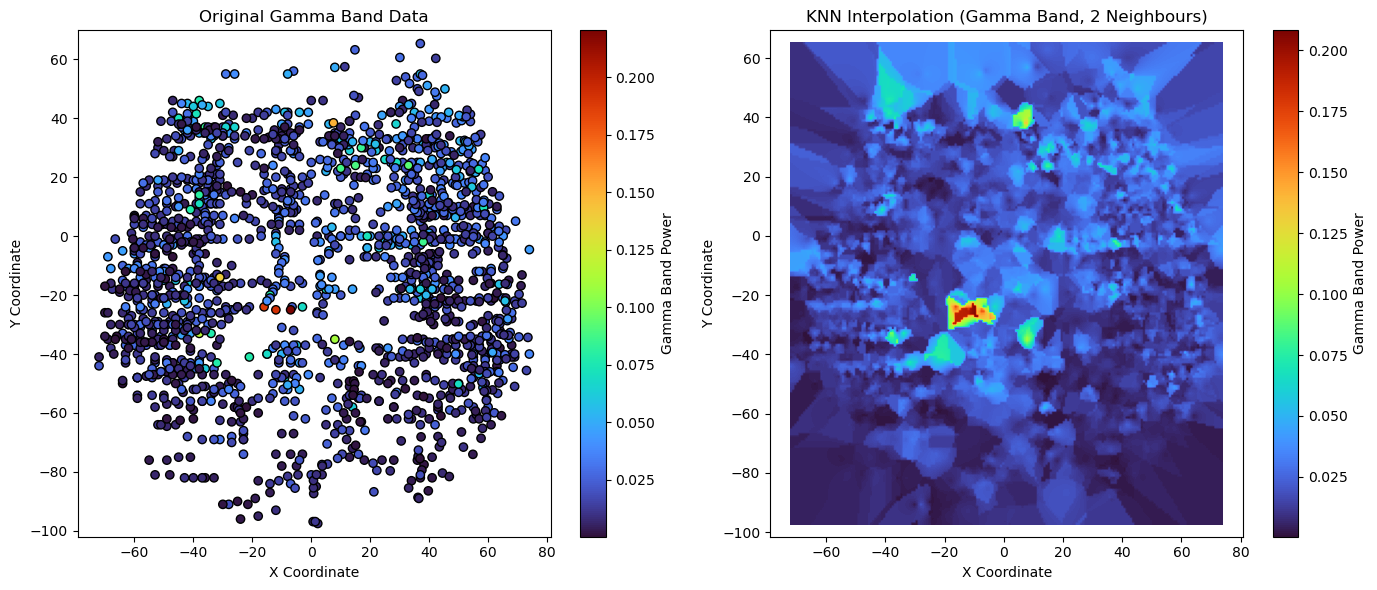


KNN Interpolation Evaluation Metrics (2 Neighbours):
            MSE       MAE      RMSE        R²
Delta  0.000201  0.003256  0.014174  0.958211
Theta  0.000095  0.002183  0.009766  0.960280
Alpha  0.000126  0.002092  0.011206  0.947129
Beta   0.000131  0.002558  0.011461  0.974383
Gamma  0.000013  0.000758  0.003611  0.961219

Performing KNN Interpolation with 10 Neighbours...

Processing Delta Band...


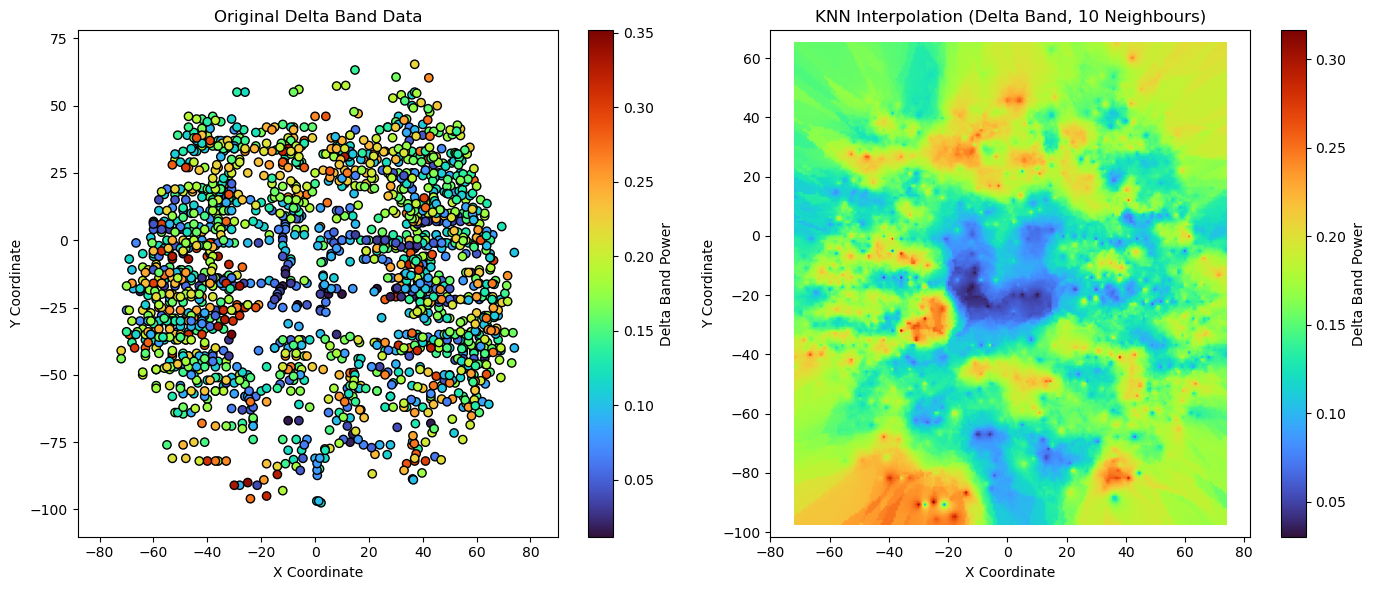

Processing Theta Band...


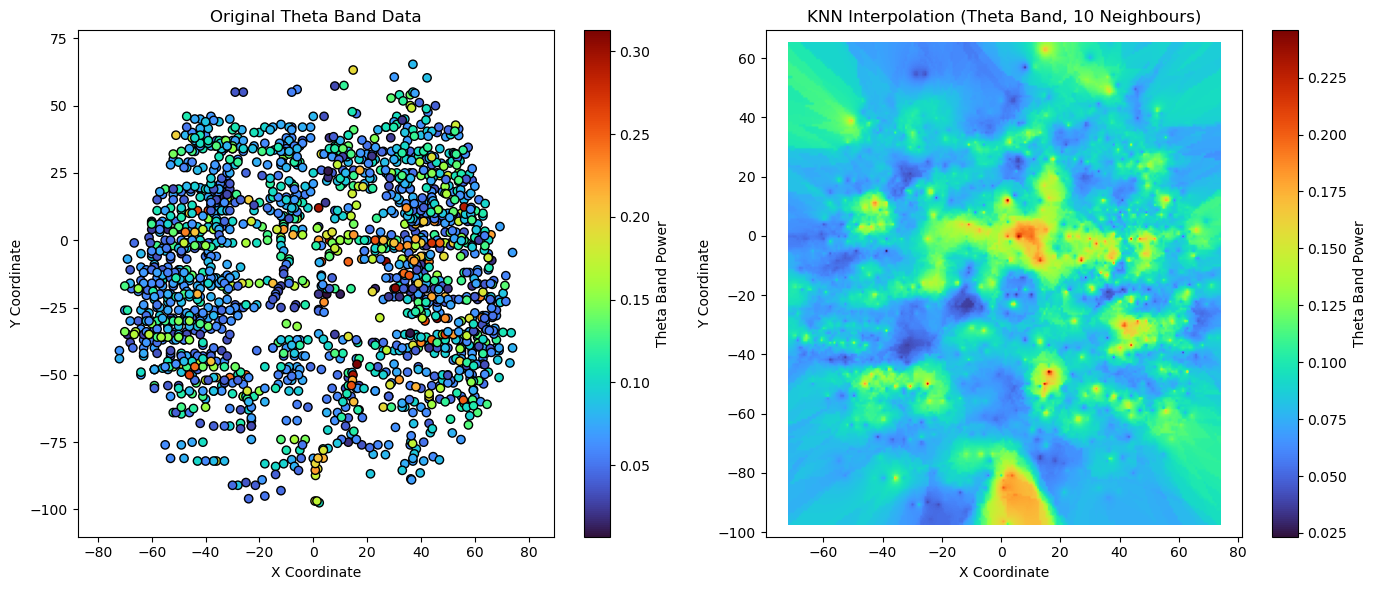

Processing Alpha Band...


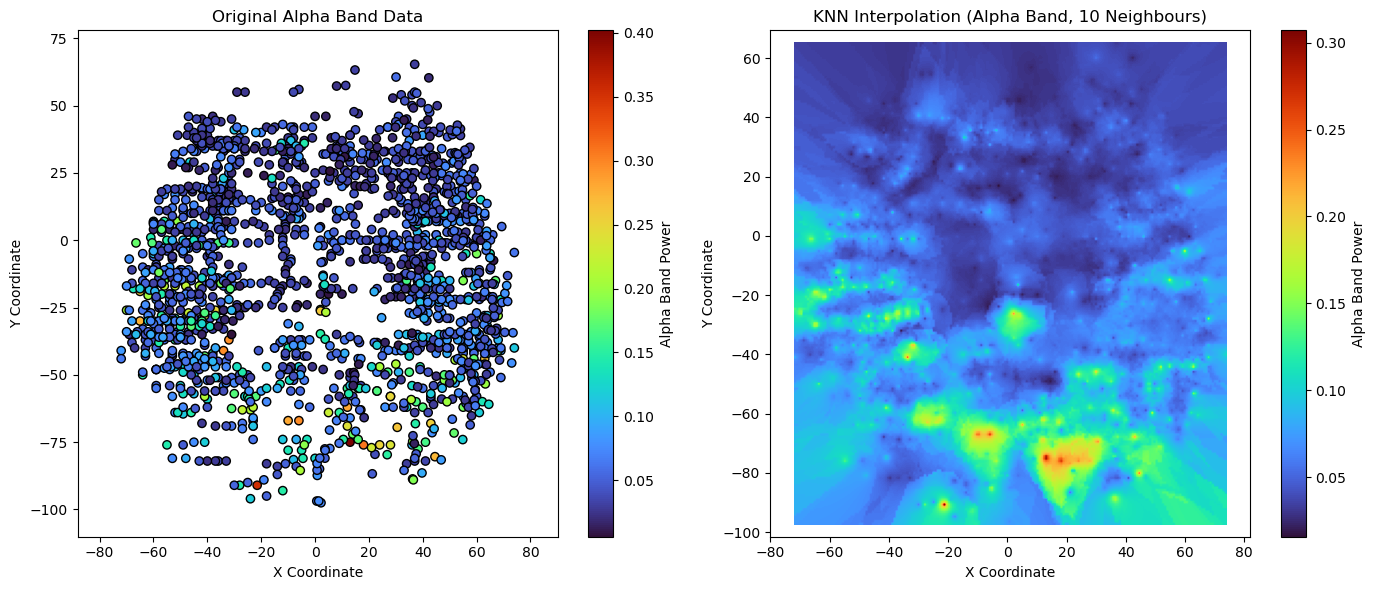

Processing Beta Band...


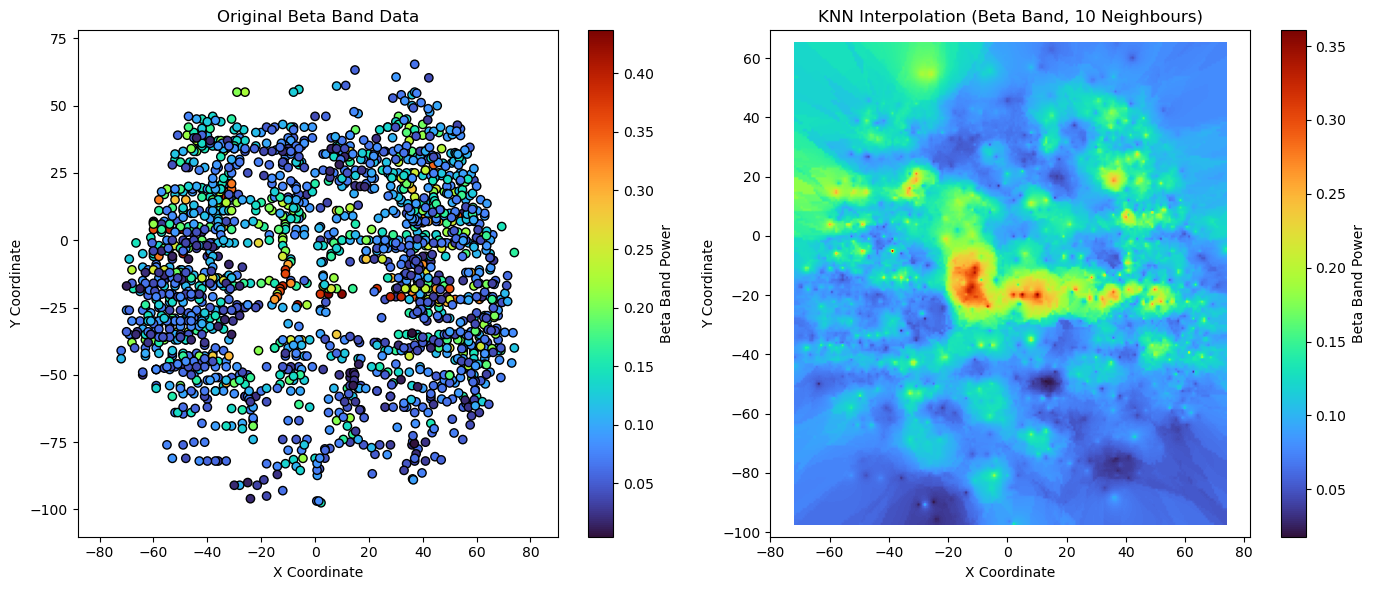

Processing Gamma Band...


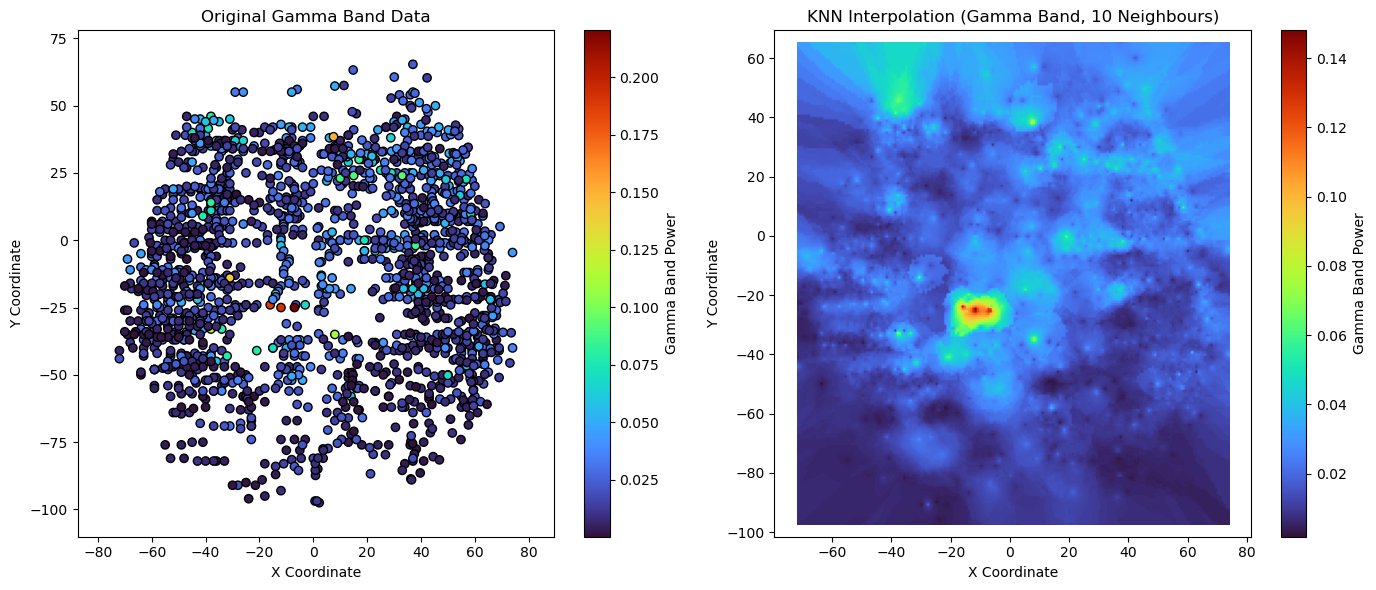


KNN Interpolation Evaluation Metrics (10 Neighbours):
            MSE       MAE      RMSE        R²
Delta  0.000199  0.003240  0.014091  0.958702
Theta  0.000090  0.002203  0.009474  0.962616
Alpha  0.000124  0.002052  0.011127  0.947866
Beta   0.000130  0.002555  0.011399  0.974659
Gamma  0.000013  0.000753  0.003602  0.961403


In [4]:
# Load the data
coords = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

# Extract x, y coordinates
x, y = coords[:, 0], coords[:, 1]
xy_points = np.column_stack((x, y))  # Create a 2D array of coordinates

# Define a grid for interpolation
resolution = 200
grid_x, grid_y = np.meshgrid(
    np.linspace(min(x), max(x), resolution),
    np.linspace(min(y), max(y), resolution)
)

# Flatten the grid for KNN predictions
grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))

# Function to perform KNN interpolation and evaluation
def knn_interpolation(n_neighbors):
    print(f'\nPerforming KNN Interpolation with {n_neighbors} Neighbours...\n')

    evaluation_metrics = {}

    # Iterate over each frequency band
    for band, values in band_powers.items():
        print(f'Processing {band} Band...')

        # Initialise KNN Regressor
        knn = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')

        # Fit the KNN model to the band power data
        knn.fit(xy_points, values)

        # Predict interpolated values for the grid
        grid_values = knn.predict(grid_points).reshape(grid_x.shape)

        # Evaluate interpolation accuracy by comparing interpolated values at original sample points
        interp_values_at_samples = knn.predict(xy_points)

        mse = mean_squared_error(values, interp_values_at_samples)
        mae = mean_absolute_error(values, interp_values_at_samples)
        rmse = sqrt(mse)
        r2 = r2_score(values, interp_values_at_samples)

        evaluation_metrics[band] = {
            "MSE": mse,
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        }

        # Plot original vs interpolated data
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Scatter plot of original data
        sc = axes[0].scatter(x, y, c=values, cmap='turbo', edgecolors='k')
        axes[0].set_title(f'Original {band} Band Data')
        axes[0].set_xlabel('X Coordinate')
        axes[0].set_ylabel('Y Coordinate')
        axes[0].axis('equal')
        fig.colorbar(sc, ax=axes[0], label=f'{band} Band Power')

        # Heatmap of interpolated data
        i = axes[1].imshow(grid_values, extent=(min(x), max(x), min(y), max(y)), origin='lower', cmap='turbo')
        axes[1].set_title(f'KNN Interpolation ({band} Band, {n_neighbors} Neighbours)')
        axes[1].set_xlabel('X Coordinate')
        axes[1].set_ylabel('Y Coordinate')
        axes[1].axis('equal')
        fig.colorbar(i, ax=axes[1], label=f'{band} Band Power')

        plt.tight_layout()
        plt.show()

    # Convert evaluation metrics into table and display them
    df_metrics = pd.DataFrame(evaluation_metrics).T
    print(f"\nKNN Interpolation Evaluation Metrics ({n_neighbors} Neighbours):")
    print(df_metrics)

    return df_metrics

# Run KNN interpolation separately for different neighbor values
df_metrics_2 = knn_interpolation(2)
df_metrics_10 = knn_interpolation(10)


### KNN with 5 Neighbours:

In [5]:
def knn_interpolation(n_neighbors):
    print(f'\nPerforming KNN Interpolation with {n_neighbors} Neighbours...\n')

    evaluation_metrics = {}

    # Iterate over each frequency band
    for band, values in band_powers.items():
        print(f'Processing {band} Band...')

        # Initialise KNN Regressor
        knn = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')

        # Fit the KNN model to the band power data
        knn.fit(xy_points, values)

        # Predict interpolated values for the grid
        grid_values = knn.predict(grid_points).reshape(grid_x.shape)

        # Evaluate interpolation accuracy by comparing interpolated values at original sample points
        interp_values_at_samples = knn.predict(xy_points)

        mse = mean_squared_error(values, interp_values_at_samples)
        mae = mean_absolute_error(values, interp_values_at_samples)
        rmse = sqrt(mse)
        r2 = r2_score(values, interp_values_at_samples)

        evaluation_metrics[band] = {
            "MSE": mse,
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        }

    # Convert evaluation metrics into table and return it
    df_metrics = pd.DataFrame(evaluation_metrics).T
    print(f"\nKNN Interpolation Evaluation Metrics ({n_neighbors} Neighbours):")
    print(df_metrics)
    
    return df_metrics

# Generate the evaluation metrics for 5 neighbours
df_metrics_5 = knn_interpolation(5)



Performing KNN Interpolation with 5 Neighbours...

Processing Delta Band...
Processing Theta Band...
Processing Alpha Band...
Processing Beta Band...
Processing Gamma Band...

KNN Interpolation Evaluation Metrics (5 Neighbours):
            MSE       MAE      RMSE        R²
Delta  0.000199  0.003240  0.014091  0.958702
Theta  0.000090  0.002203  0.009474  0.962616
Alpha  0.000124  0.002052  0.011127  0.947866
Beta   0.000130  0.002555  0.011399  0.974659
Gamma  0.000013  0.000753  0.003602  0.961403


### Comparing KNN Interpolation Across 2, 5, and 10 Neighbours

In [6]:
# Combine evaluation metrics into a single DataFrame
df_comparison = pd.concat(
    [df_metrics_2.rename(columns=lambda x: f"{x} (2 Neighbours)"),
     df_metrics_5.rename(columns=lambda x: f"{x} (5 Neighbours)"),
     df_metrics_10.rename(columns=lambda x: f"{x} (10 Neighbours)")],
    axis=1
)

# Display the comparison table
print("\nKNN Evaluation Metrics Comparison:")
print(df_comparison)



KNN Evaluation Metrics Comparison:
       MSE (2 Neighbours)  MAE (2 Neighbours)  RMSE (2 Neighbours)  \
Delta            0.000201            0.003256             0.014174   
Theta            0.000095            0.002183             0.009766   
Alpha            0.000126            0.002092             0.011206   
Beta             0.000131            0.002558             0.011461   
Gamma            0.000013            0.000758             0.003611   

       R² (2 Neighbours)  MSE (5 Neighbours)  MAE (5 Neighbours)  \
Delta           0.958211            0.000199            0.003240   
Theta           0.960280            0.000090            0.002203   
Alpha           0.947129            0.000124            0.002052   
Beta            0.974383            0.000130            0.002555   
Gamma           0.961219            0.000013            0.000753   

       RMSE (5 Neighbours)  R² (5 Neighbours)  MSE (10 Neighbours)  \
Delta             0.014091           0.958702             0.0001

### Which KNN Neighbour Count Works Best?

- **2 Neighbors** → Best for fine details, lowest error, but can be noisy.  
- **10 Neighbors** → Smooths interpolation but may lose accuracy.  
- **5 Neighbors** → A good balance between detail and smoothness.  

**Best Pick?**  
**5 Neighbors** — keeps accuracy while reducing noise. 
